# **Meshlands - Budyko Curve**
The Budyko Curve describes the relationship between the **evaporative index (AET/P)** and the **dryness index (PET/P)**.\
\
The dryness index corresponds to the ratio over a given location between the potential evapotranspiration (based on the local radiative budget, calculated here thanks to the Priestley-Taylor formula) from land and the total precipitation rate.\
The evaporative index corresponds to the ratio between the actual evapotranspiration and the total precipitation rate at a given location.\
\
The Budyko Curve allows us to conclude whether a specific geographical location is moisture-limited or energy-limited to evaporated water. Concretely, a dryness index lower than 1 defines an energy-limited evaporation process, while a dryness index higher than 1 defines a water-limited process.

<div style="background-color:#fff3cd; border-left: 6px solid #ffa500; padding: 10px; margin: 10px 0;">
  <strong>Warning:</strong> this notebook uses the Pyet library to compute the dryness index and the potential evapotranspiration (PET) based on the radiative fluxes.
</div>

## **Initial Set-Up Related**

### Imports

In [1]:
%matplotlib inline
import sys
sys.path.append('./scripts')

########## Plotting (Matplotlib) ##########
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap
white_cmap = ListedColormap(['white'])

########## Python Standard Library ##########
from copy import copy
import glob

########## Pyet ###########
import pyet

########## Cartopy ##########
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

########## Dask ##########
import dask

########## NumPy ##########
import numpy as np

########## SciPy ##########
from scipy.optimize import curve_fit

########## Xarray ##########
import xarray as xr

### Function Definitions

In [2]:
def fu_equation(x, omega):
    '''
    Calculates the Fu formula (for the Budyko Curve parametric model)

    Args:
        x (array): dryness index
        omega (float): parameter that will be adjusted

    Return:
        Fu formula
    '''
    return 1 + x - (1 + x**omega)**(1 / omega)

### Path Definitions

In [3]:
# Data Path
data_dir = '/scratch/st-mlague-1/mlague/data/cesm_meshland/'

### Variable Definitions

In [4]:
# Creates a list of atmospheric variables
atm_vars = ['PRECL','PRECC','FSNS','FLNS','TREFHT','PS','LHFLX']

### Dictionary Definitions

In [5]:
# Creates a new case list
case_list = ['cesm_f09_mesh4_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh8_avgemiss_450ppm_thermice2',
             'cesm_f09_mesh16_avgemiss_450ppm_thermice2']

# Creates a dictionary of the short names for each case in case_list
short_names = {}
short_names['cesm_f09_mesh4_avgemiss_450ppm_thermice2'] = 'mesh4'
short_names['cesm_f09_mesh8_avgemiss_450ppm_thermice2'] = 'mesh8'
short_names['cesm_f09_mesh16_avgemiss_450ppm_thermice2'] = 'mesh16'

# create a list of cases
config = list(short_names.values())

In [6]:
# Creates an empty data set dictionary
ds_dict = {}

# Creates an empty time series dictionary for the atmospheric variables
ts_dict_atm = {}

# Creates an empty dictionary for the meshlands geographical configuration
mesh_dict = {}
mesh4_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland4.nc")
mesh8_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland8.nc")
mesh16_dict = xr.open_dataset("/scratch/st-mlague-1/mlague/data/cesm_meshland/inputs/fracdata_0.9x1.25_meshland16.nc")
mesh_dict['mesh4'] = mesh4_dict
mesh_dict['mesh8'] = mesh8_dict
mesh_dict['mesh16'] = mesh16_dict

# Overall: using dask to split large chunks of the array to avoid a surcharge
with dask.config.set(**{'array.slicing.split_large_chunks': True}):

    # For each case in the case list,
    # prints the name of the case
    for case in case_list:
        print(case)

        # Defines the time series directory name for the case
        ts_dir = data_dir + '/' + case + '/TimeSeries/'

        # Creates an empty file list for the atmospheric variables
        file_list_atm = []

        # For each variable in the set of atmospheric variables
        for var in atm_vars:

            # Finds the variable's file for that case
            files = glob.glob(ts_dir+'/'+case+'.cam.h0.ts.0-end.'+var+'.nc')

            # If the file does not exist, print a message
            # Else, append the files to the atmospheric file list
            if len(files)<1:
                print('oh no, no variables for %s'%var)
            else:
                for file in files:
                    file_list_atm.append(file)

        # Creates temporary atmospheric and land data sets
        ds_temp_atm = xr.open_mfdataset(file_list_atm,engine='netcdf4',compat='override')

        # Drops the first 30 years, and keeps data up to year 60
        if case == 'cesm_f09_mesh16_avgemiss_450ppm_thermice2':
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((27-1)*12-1,56*12-1))
        else:
            ds_temp_atm_short = ds_temp_atm.isel(time=slice((30-1)*12-1,60*12-1))

        # Assigns the case's short name to short
        short = short_names[case]

        # Creates a copy of the temporary atmospheric and land data sets,
        # then assigns them to an entry in their respective dictionaries
        ts_dict_atm[short] = copy(ds_temp_atm_short)

        # Deletes the temporary data sets
        del ds_temp_atm, ds_temp_atm_short

cesm_f09_mesh4_avgemiss_450ppm_thermice2
cesm_f09_mesh8_avgemiss_450ppm_thermice2
cesm_f09_mesh16_avgemiss_450ppm_thermice2


# **Dryness Index**

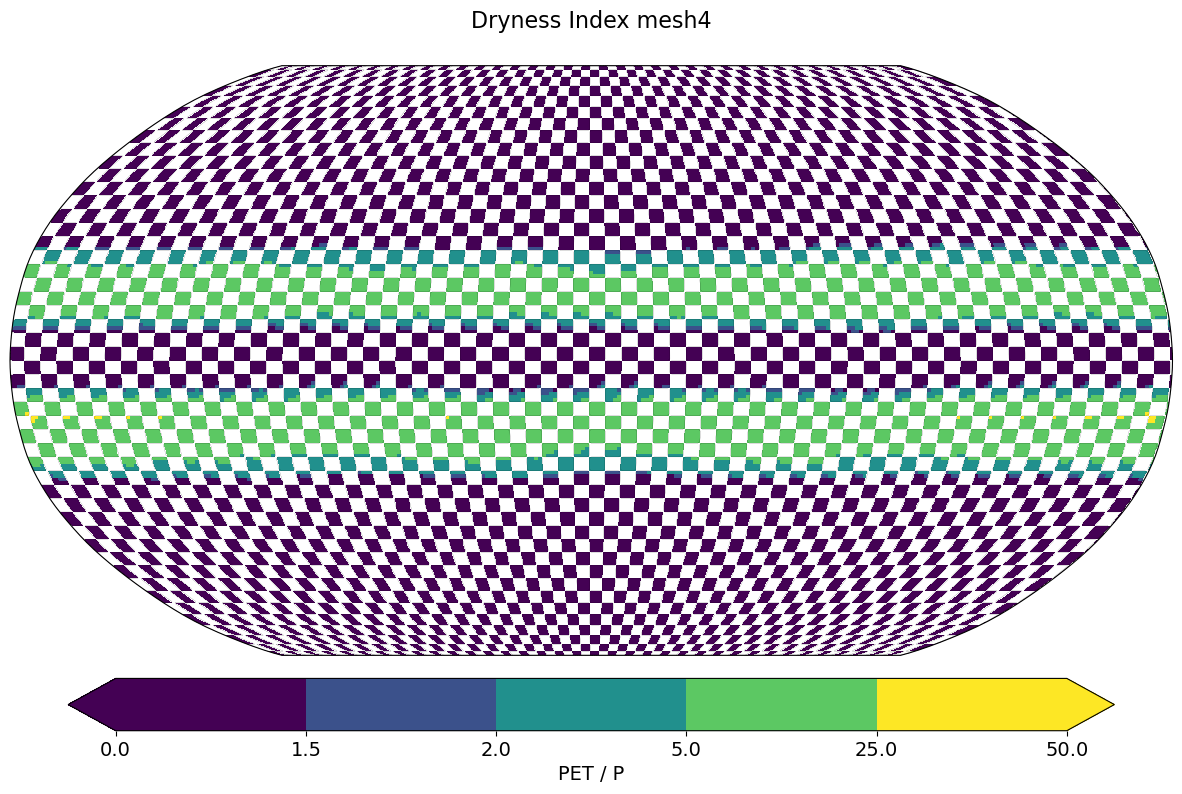

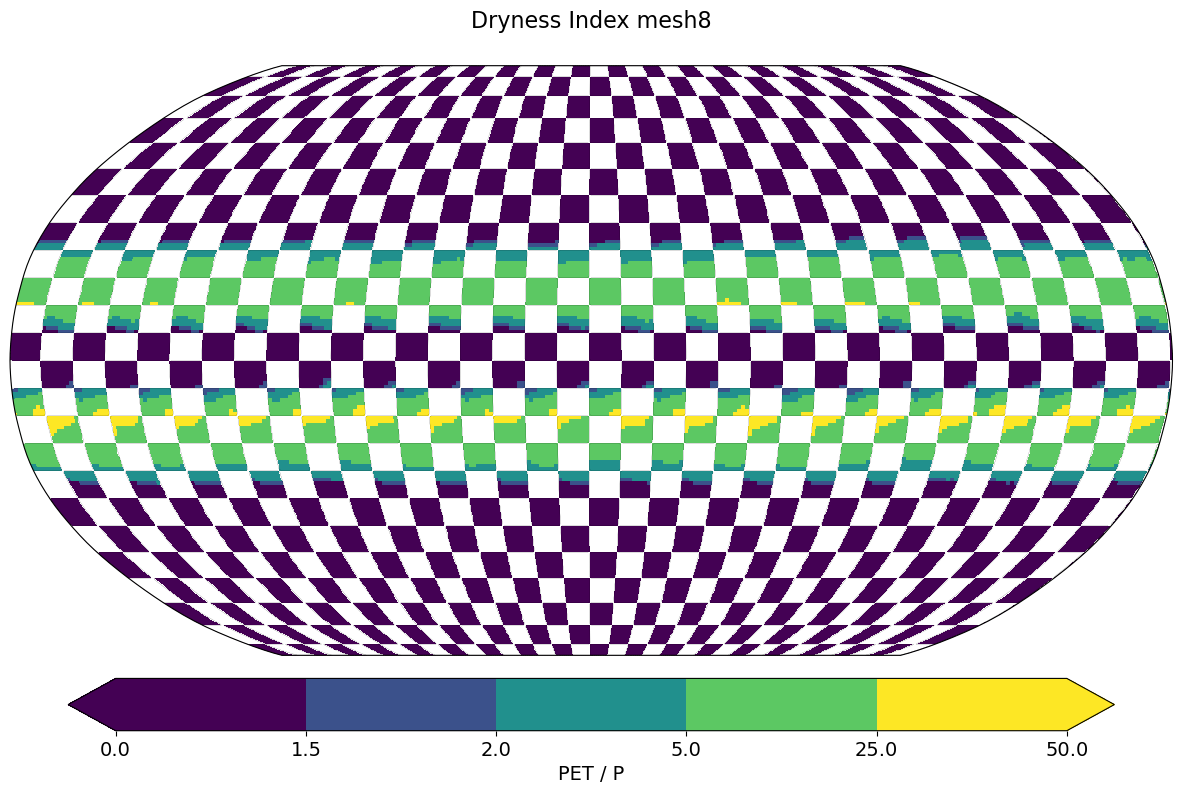

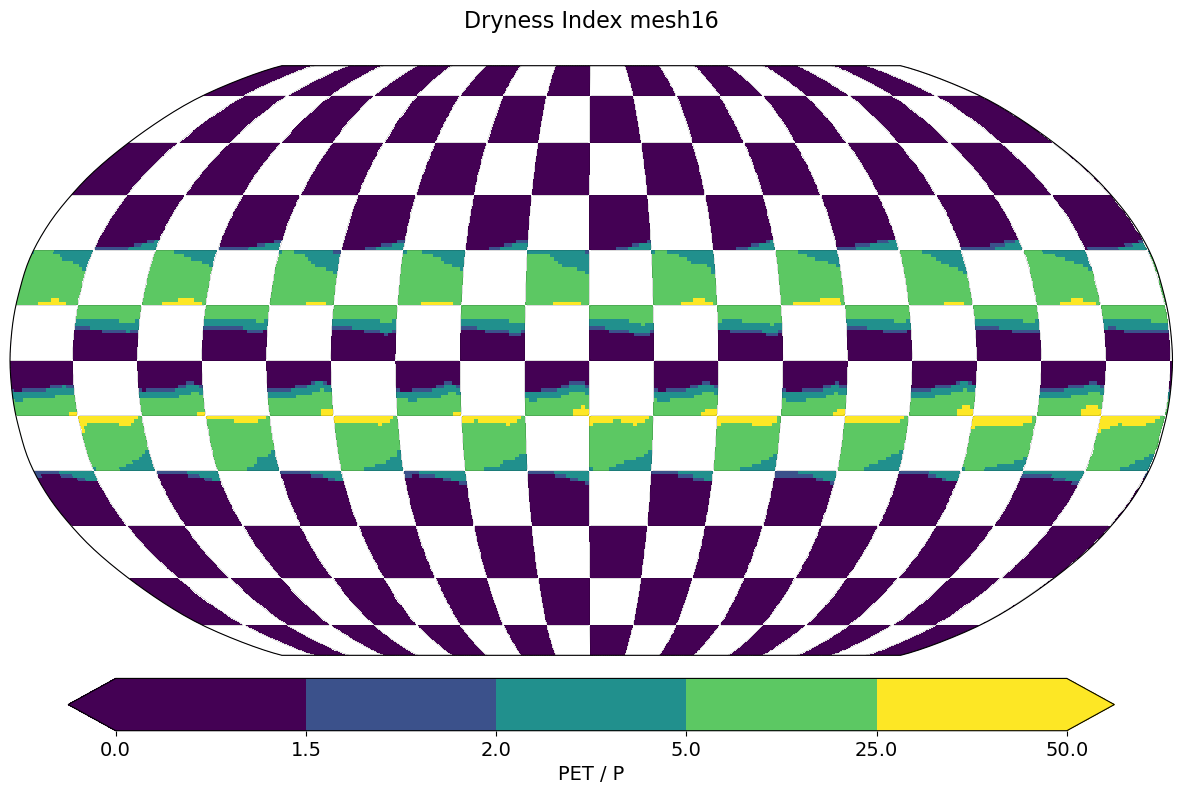

In [7]:
# Overall: plots separately the dryness index for all meshes

# Creates an empty dictionary to store the PET values
PET_dict = {}

for case in ['mesh4','mesh8','mesh16']:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case]
    
    # Loads CAM radiation needed
    FSNS = ds_case['FSNS']  # W/m2
    FLNS = ds_case['FLNS']  # W/m2

    # Converts net radiation, W/m2 -> MJ/m2/day
    Rn_Wm2 = FSNS - FLNS
    Rn = Rn_Wm2 * 1e-6 * 3600 * 24   # W/m2 * 86400 s/day / 1e6 J/MJ = 0.0864

    # Converts temperature, K -> C
    TREFHT = ts_dict_atm[case]['TREFHT']
    T = TREFHT - 273.15

    # Converts surface pressure (Pa) -> elevation is what pyet actually wants
    PS = ts_dict_atm[case]['PS']  # Pa
    P_kPa = PS / 1000

    # Uses the priestley_taylor formula
    PET = pyet.priestley_taylor(T, rn=Rn, pressure=P_kPa) # returns PET in mm/day, same dims/coords as inputs

    # Adds the result to the storage dictionary
    PET_dict[case] = PET

    # Calculates the total precipitation rate
    PRECC = ds_case['PRECC'].groupby('time.year').mean('time')
    PRECL = ds_case['PRECL'].groupby('time.year').mean('time')
    P = (PRECC + PRECL) * 1000 * 3600 * 24
    Pre_tot = P.mean('year')

    # Calculates the dryness index
    mapdata = PET_dict[case].mean('time') / Pre_tot
    
    ttl = 'Dryness Index %s'%(case)
    
    fig = plt.figure(figsize=(15,15))
    
    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects coordinates to plot the coastlines
    xc_cyc = np.concatenate([mesh_dict[case]["xc"], mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh_dict[case]["yc"], mesh_dict[case]["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]], axis=1)

    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=mapdata.lon)

    # Plots the data as a coloured mesh
    levels = [0, 1.5, 2.0, 5.0, 25.0, 50]
    norm = BoundaryNorm(levels, ncolors=256)
    cs = plt.pcolormesh(cyclic_lons, mapdata.lat, cyclic_data,transform=ccrs.PlateCarree(),norm=norm)

    # Sets the colormap
    plt.set_cmap('viridis')
    plt.title(ttl,fontsize=16,y=1.05)

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend='both',pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=14) 
    cbar.set_label('PET / P',fontsize=14)
    
    # Covers ocean parts
    ocean = np.ma.masked_where(mask_cyc == 1, mask_cyc)
    ax.pcolormesh(xc_cyc,yc_cyc,ocean,transform=ccrs.PlateCarree(),cmap=white_cmap,shading='auto')
    
    plt.show()
    plt.close()

**Dryness Index Categories:**
- < 1.5       = Humid
- 1.5 to 2.0  = Dry Sub-Humid
- 2.0 to 5.0  = Semi-Arid (grasslands, savannas)
- 5.0 to 25.0 = Arid
- \> 25.0     = Hyper-Arid

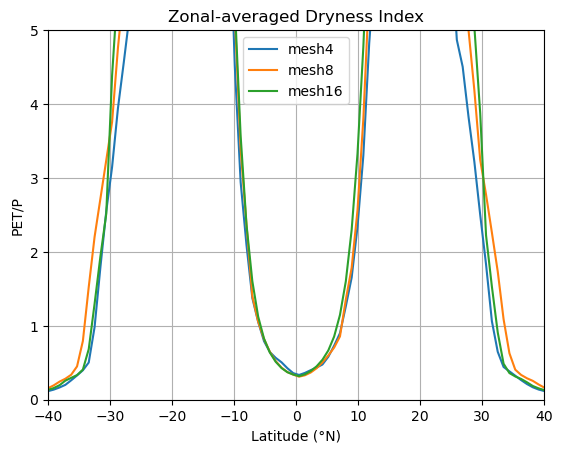

In [13]:
# Overall: plots the zonal-averaged dryness index for all experiments (over mid- to low-latitudes)

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')
    mapdata = PET_dict[case].mean('time') / ((ds_case['PRECL'].mean('year') + ds_case['PRECC'].mean('year')) * 3600 * 24 * 1000)

    # Collects the case mask to conserve only land values
    mask = mesh_dict[case]['mask'].values
    lnd = mapdata.where(mask == 1).mean('lon')

    plt.plot(lnd.lat,lnd,label=case)
    
plt.xlabel('Latitude (°N)')
plt.xlim([-40,40])
plt.ylim([0,5])
plt.ylabel('PET/P')

plt.legend()
plt.grid()

plt.title('Zonal-averaged Dryness Index')

plt.show()
plt.close()

# **Evaporative Index**

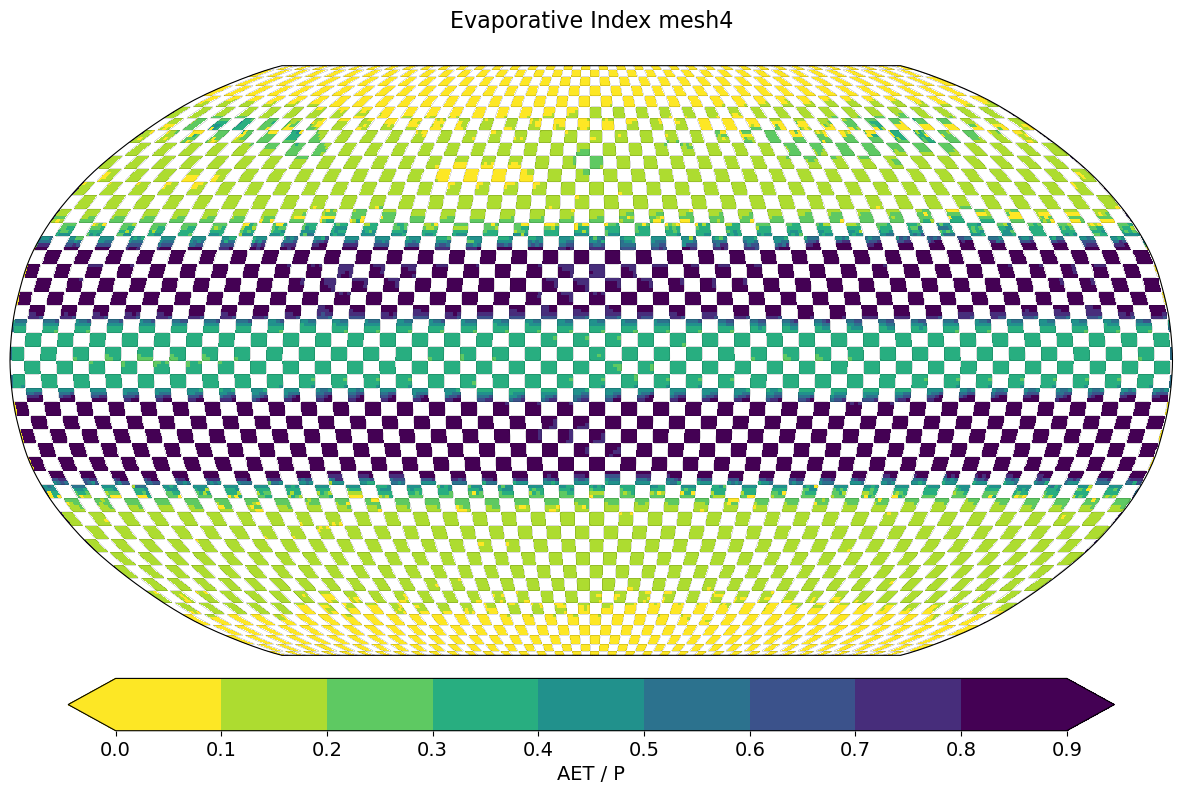

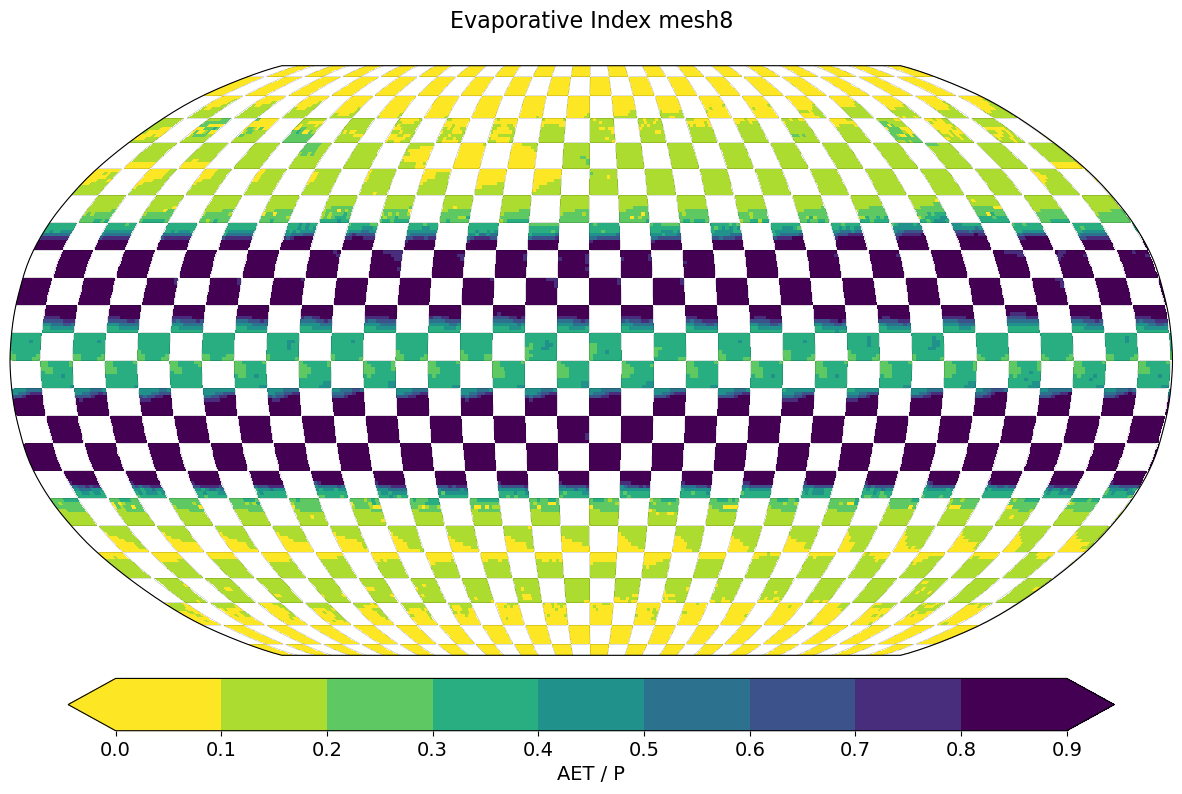

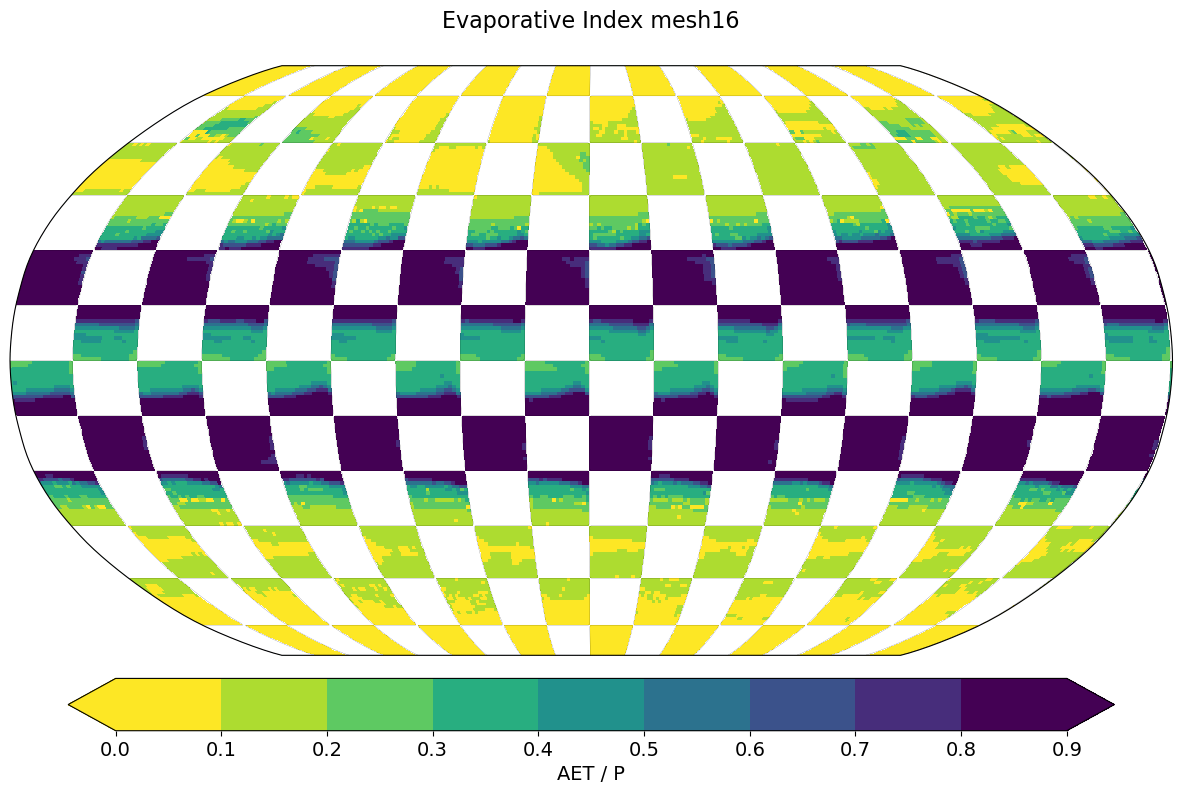

In [10]:
# Overall: plots separately the evaporative index for each case

# Creates an empty dictionary to store the data
AET_dict = {}

for case in ['mesh4','mesh8','mesh16']:
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case]
    
    # Loads CAM Latent heat flux
    LHFLX = ds_case['LHFLX'].groupby('time.year').mean('time')  # W/m2
    L = 2.501e6 # Latent heat of vaporization (J/kg)

    # Converts the actual evapotranspiration unit
    AET = LHFLX.mean('year') / L * 3600*24 # mm/s --> mm/day

    # Adds to the storage dictionary
    AET_dict[case] = AET

    # Calculates the total precipitation rate
    PRECC = ds_case['PRECC'].groupby('time.year').mean('time')
    PRECL = ds_case['PRECL'].groupby('time.year').mean('time')
    P = (PRECC + PRECL) * 1000 * 3600 * 24
    Pre_tot = P.mean('year')

    # Prepares the mapdata
    mapdata = AET_dict[case] / Pre_tot
    
    ttl = 'Evaporative Index %s'%(case)
    
    fig = plt.figure(figsize=(15,15))
    
    # Specifies a Robinson projection map
    ax = plt.axes(projection=ccrs.Robinson())

    # Collects coordinates to plot the coastlines
    xc_cyc = np.concatenate([mesh_dict[case]["xc"], mesh_dict[case]["xc"][:, :1] + 360], axis=1)
    yc_cyc = np.concatenate([mesh_dict[case]["yc"], mesh_dict[case]["yc"][:, :1]], axis=1)
    mask_cyc = np.concatenate([mesh_dict[case]["mask"], mesh_dict[case]["mask"][:, :1]], axis=1)
    # Draws coastlines
    ax.contour(xc_cyc,yc_cyc,mask_cyc,levels=[0.5],colors="black",linewidths=0.1,transform=ccrs.PlateCarree())
    
    # Sets the view to be the entire globe
    ax.set_global()

    # Creates a cyclic point to ensure longitude plots smoothly 
    cyclic_data, cyclic_lons = add_cyclic_point(mapdata,coord=mapdata.lon)

    # Plots the data as a coloured mesh
    levels = np.arange(0,1,0.1)
    norm = BoundaryNorm(levels, ncolors=256)
    cs = plt.pcolormesh(cyclic_lons, mapdata.lat, cyclic_data,transform=ccrs.PlateCarree(),norm=norm)
    
    # Sets cmap characteristics
    plt.set_cmap('viridis_r')
    plt.title(ttl,fontsize=16,y=1.05)

    # Sets the colour bar parameters
    cbar = plt.colorbar(ax=ax,orientation='horizontal',extend='both',pad=.02, shrink=0.9)
    cbar.ax.tick_params(labelsize=14) 
    cbar.set_label('AET / P',fontsize=14)
    
    # Covers ocean parts
    ocean = np.ma.masked_where(mask_cyc == 1, mask_cyc)
    ax.pcolormesh(xc_cyc,yc_cyc,ocean,transform=ccrs.PlateCarree(),cmap=white_cmap,shading='auto')
    
    plt.show()
    plt.close()

# **Budyko Curve**

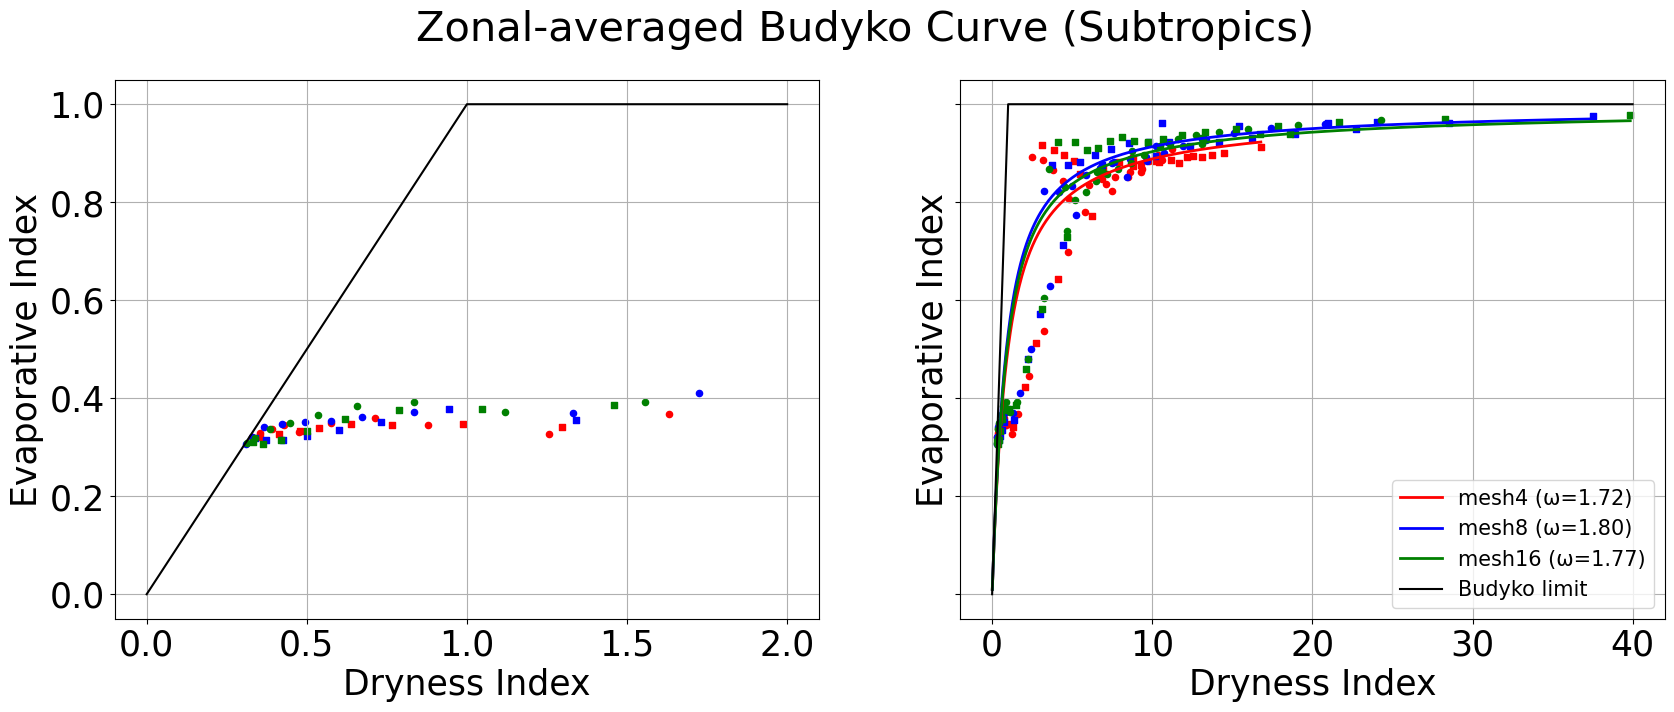

In [12]:
# Overall: plots the Budyko Curve for each experiment, with a zoom into the low values of the dryness index for a better analysis

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)

# Creates empty lists to store values used for the interpolation
dry_index_dict = {'mesh4' : [],
                  'mesh8' : [],
                  'mesh16' : []}
evap_index_dict = {'mesh4' : [],
                   'mesh8' : [],
                   'mesh16' : []}

for (i,case) in enumerate(['mesh4','mesh8','mesh16']) :
    # Groups the case's atmospheric time series dictionary by year, calculates the mean
    ds_case = ts_dict_atm[case].groupby('time.year').mean('time')

    # Collects the cases' mask data to plot only the land index
    mask = mesh_dict[case]['mask'].values
    PET_land = PET_dict[case].where(mask == 1).mean('time').mean('lon')
    AET_land = AET_dict[case].where(mask == 1).mean('lon')

    # Calculates the total precipitation rate
    Pre_tot = ds_case['PRECL'].where(mask == 1).mean('year') + ds_case['PRECC'].where(mask == 1).mean('year')
    P = Pre_tot.mean('lon') * 1000 * 3600 * 24

    # Generates a loop to plot data at each latitude 
    for lat,lat_val in enumerate(ds_case.lat.values) :

        # Calculates the position on the curve
        dry_index = PET_land.isel(lat=lat).values / P.isel(lat=lat)
        evap_index = AET_land.isel(lat=lat).values / P.isel(lat=lat)

        dry_index_dict[case].append(dry_index)
        evap_index_dict[case].append(evap_index)

        # Isolates southern subtropics
        if lat_val < 0 and lat_val >= -30 :
            if case == 'mesh4':
                # Makes the dot appear in the zoom plot
                if dry_index <= 2 :
                    axes[0].scatter(dry_index, evap_index, s=20, color='r', marker='s')
                axes[1].scatter(dry_index, evap_index, s=20, color='r', marker='s')                    
            elif case == 'mesh8':
                # Makes the dot appear in the zoom plot
                if dry_index <= 2 :
                    axes[0].scatter(dry_index, evap_index, s=20, color='b', marker='s')
                axes[1].scatter(dry_index, evap_index, s=20, color='b', marker='s')                    
            else :
                # Makes the dot appear in the zoom plot                
                if dry_index <= 2 :
                    axes[0].scatter(dry_index, evap_index, s=20, color='g', marker='s')
                axes[1].scatter(dry_index, evap_index, s=20, color='g', marker='s')                    

        # Isolates northern subtropics
        elif lat_val >= 0 and lat_val < 30 :
            if case == 'mesh4' :
                # Makes the dot appear in the zoom plot                
                if dry_index <= 2 :
                    axes[0].scatter(dry_index, evap_index, s=20, color='r', marker='o')
                axes[1].scatter(dry_index, evap_index, s=20, color='r', marker='o')
            elif case == 'mesh8' :
                # Makes the dot appear in the zoom plot
                if dry_index <= 2 :
                    axes[0].scatter(dry_index, evap_index, s=20, color='b', marker='o')
                axes[1].scatter(dry_index, evap_index, s=20, color='b', marker='o')
            else :
                # Makes the dot appear in the zoom plot
                if dry_index <= 2 :
                    axes[0].scatter(dry_index, evap_index, s=20, color='g', marker='o')
                axes[1].scatter(dry_index, evap_index, s=20, color='g', marker='o')

# Calculates and draw the interpolation
for case in ['mesh4', 'mesh8', 'mesh16']:
    # Definition of the axes based on the dictionaries
    x = np.array(dry_index_dict[case])
    y = np.array(evap_index_dict[case])

    # Adjusts the y values with the fu formula (the best possible fit)
    popt, _ = curve_fit(fu_equation, x, y, p0=[2.0], maxfev=5000)

    # Creates arrays to plot the fitted curve
    x_fit = np.linspace(0.01, x.max(), 300)
    y_fit = fu_equation(x_fit, *popt)

    # Plots the interpolation
    if case == 'mesh4' :
        axes[1].plot(x_fit, y_fit, color='r', linewidth=2, label=f'{case} (ω={popt[0]:.2f})')
    elif case == 'mesh8' :
        axes[1].plot(x_fit, y_fit, color='b', linewidth=2, label=f'{case} (ω={popt[0]:.2f})')
    else :
        axes[1].plot(x_fit, y_fit, color='g', linewidth=2, label=f'{case} (ω={popt[0]:.2f})')
    
axes[0].set_xlabel('Dryness Index',fontsize=25)
axes[1].set_xlabel('Dryness Index',fontsize=25)

axes[0].set_ylabel('Evaporative Index',fontsize=25)
axes[1].set_ylabel('Evaporative Index',fontsize=25)

axes[0].tick_params(labelsize=25)
axes[1].tick_params(labelsize=25)

# Draws the ideal Budyko Curve for comparison
axes[0].plot([0, 1, 2], [0, 1, 1], color='k', linestyle='-', linewidth=1.5, label='Budyko limit')
axes[1].plot([0, 1, 40], [0, 1, 1], color='k', linestyle='-', linewidth=1.5, label='Budyko limit')

axes[0].grid()
axes[1].grid()

plt.suptitle('Zonal-averaged Budyko Curve (Subtropics)', fontsize=30)
plt.legend(fontsize=15)

plt.show()
plt.close()

**Information about the plot:**
- The left plot is a zoom in the low values of the dryness index, with the right plot representing the totality of the values.
- Each configuration is represented by a specific color: Mesh4 = red, Mesh8 = blue, Mesh16 = green.
- The plot displaying only subtropics latitudes, the northern hemisphere is signified by the dots while the southern hemisphere is represented by squares.